# Nuclear NPV simulation

Run the nuclear electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_nuclear_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_nuclear_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,nuclear,1000000.0,5300.0,188.679245,188679.245283,14477.925335,102.317272,6.090251,2.902845,...,94070000.0,1.930515e+07,6.090251e+06,2.322276e+07,0.0,4.545184e+07,-2.163794e+09,100000000.0,-21.637943,-0.000022
1,1,nuclear,1000000.0,5300.0,188.679245,188679.245283,6398.483162,114.099214,5.662032,2.882138,...,94070000.0,2.152815e+07,5.662032e+06,2.305710e+07,0.0,4.382271e+07,-6.597261e+08,100000000.0,-6.597261,-0.000007
2,2,nuclear,1000000.0,5300.0,188.679245,188679.245283,10717.495173,100.384761,6.816776,2.888171,...,94070000.0,1.894052e+07,6.816776e+06,2.310537e+07,0.0,4.520733e+07,-1.457334e+09,100000000.0,-14.573341,-0.000015
3,3,nuclear,1000000.0,5300.0,188.679245,188679.245283,9477.616166,113.904573,7.727017,2.865050,...,94070000.0,2.149143e+07,7.727017e+06,2.292040e+07,0.0,4.193115e+07,-1.264328e+09,100000000.0,-12.643283,-0.000013
4,4,nuclear,1000000.0,5300.0,188.679245,188679.245283,12275.709503,94.017853,6.252232,2.802773,...,94070000.0,1.773922e+07,6.252232e+06,2.242218e+07,0.0,4.765637e+07,-1.720738e+09,100000000.0,-17.207378,-0.000017


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-1519.469693,-15.194697,-0.000015
std,545.543482,5.455435,0.000005
min,-2545.445888,-25.454459,-0.000025
5%,-2369.179763,-23.691798,-0.000024
50%,-1519.476058,-15.194761,-0.000015
95%,-670.674348,-6.706743,-0.000007
max,-508.697867,-5.086979,-0.000005


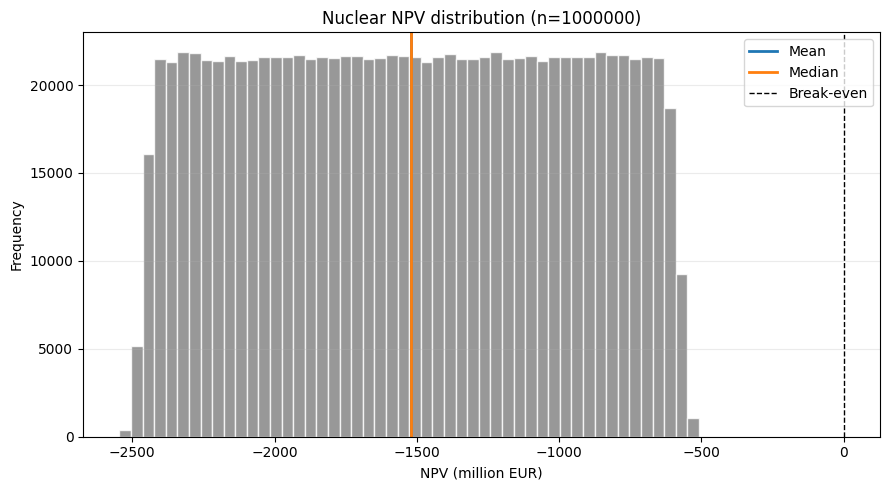

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


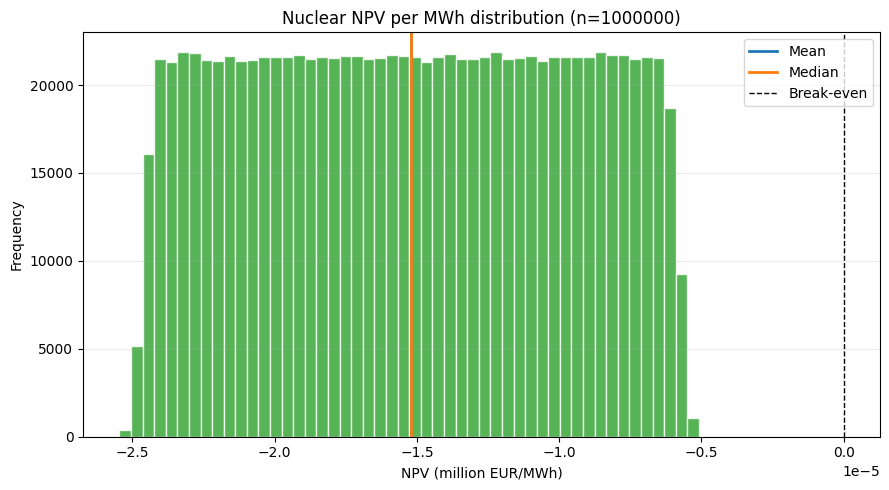

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        19.494461
annual_variable_opex_eur      7.233866
annual_fuel_cost_eur         22.881352
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     44.460322
Name: Mean annual value, million EUR, dtype: float64